# X-MACE Ethene To Propene Transfer Learning

Another TL example that uses the newly defined wrapper classes/functions. 
This time train on ethene dataset and compare with full propene dataset (baseline)
Afterwards attempt TL by doing 
    1) Random sampling + Naive TL
    2) Random sampling + Frozen-GNN 
    3) FPS + Naive TL
    4) FPS + Frozen-GNN 

Key thing is that here we start to evaluate with tester on tangible metrics like MAE or RMSE.
We target about 0.04 eV for chemical accuracy as a decent error? 
But this uses a lightweight model so results dont exactly mean too much also

## 1. Setup And Data Splitting

In [5]:
import os
from pathlib import Path

TUTORIAL_ROOT = Path(os.getcwd())
XYZ_DIR = TUTORIAL_ROOT / "data" / "xyz"
OUTPUT_DIR = TUTORIAL_ROOT / "_outputs" / "05_new_api"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = OUTPUT_DIR / "matplotlib_cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import ase.io
import matplotlib.pyplot as plt
import numpy as np
import torch
from skmatter.sample_selection import FPS
from sklearn.model_selection import train_test_split

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import Tester
from mace.training import FreezeStrategy, NaiveStrategy, Trainer, initialise_autoencoder

DEVICE = torch.device("cpu")
SEED = 42
TRANSFER_FRACTION = 0.10
BATCH_SIZE = 16
R_MAX = 5.0
MAX_EPOCHS = 2048
BASE_LR = 1.0e-3
TRANSFER_LR = 5.0e-4
WEIGHT_DECAY = 5.0e-7
FROZEN_GNN_LAYERS = ("node_embedding", "interactions", "products")

ETHENE_FILE = XYZ_DIR / "A01_ethene_grid_static.xyz"
PROPENE_FILE = XYZ_DIR / "A02_propene_grid_static.xyz"

np.random.seed(SEED)
torch.manual_seed(SEED)

"""
Here we define the new wrapper classes that were just added 
These wrappers will be used later on for convenience
"""
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0, forces_weight=5.0, dipoles_weight=0.0,
    nacs_weight=0.0, socs_weight=0.0,
).to(DEVICE)

base_trainer = Trainer(
    max_epochs=MAX_EPOCHS, optimiser_lr=BASE_LR,
    optimiser_weight_decay=WEIGHT_DECAY, early_stopping=True, stopping_patience=15,
    restore_best=True, device=DEVICE, verbose=True,
)
transfer_trainer = Trainer(
    max_epochs=MAX_EPOCHS, optimiser_lr=TRANSFER_LR,
    optimiser_weight_decay=WEIGHT_DECAY, early_stopping=True, stopping_patience=15,
    restore_best=True, device=DEVICE, verbose=True,
)
data_builder = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
)
tester = Tester(device=DEVICE)

In [2]:
ethene_atoms = ase.io.read(ETHENE_FILE, index=":")
propene_atoms = ase.io.read(PROPENE_FILE, index=":")

"""
Two successive splits produce 80% train, 10% validation, and 10% test.
We withhold the test set completely to check the results independently from training 
"""
ethene_train_atoms, ethene_holdout_atoms = train_test_split(
    ethene_atoms, test_size=0.2, random_state=SEED, shuffle=True
)
ethene_valid_atoms, ethene_test_atoms = train_test_split(
    ethene_holdout_atoms, test_size=0.5, random_state=SEED, shuffle=True
)

propene_train_atoms, propene_holdout_atoms = train_test_split(
    propene_atoms, test_size=0.2, random_state=SEED, shuffle=True
)
propene_valid_atoms, propene_test_atoms = train_test_split(
    propene_holdout_atoms, test_size=0.5, random_state=SEED, shuffle=True
)

dataset_sizes = {
    "ethene": tuple(map(len, (ethene_train_atoms, ethene_valid_atoms, ethene_test_atoms))),
    "propene": tuple(map(len, (propene_train_atoms, propene_valid_atoms, propene_test_atoms))),
}
dataset_sizes

{'ethene': (2984, 373, 374), 'propene': (2984, 373, 374)}

## 2. Train The Full Ethene Source Model

The source model learns from all 80% of the available ethene geometries. Its restored best weights become the common starting point for all four transfer experiments.

In [3]:
"""
Using the data_builder class, all the z table atomic energy etc nonsense is settled 
Only need to input a list of atoms object (read from the xyz file)
Output will be a dataloader that can be input into the model

Note that shuffle is true only for the training trainloader, so that the data supplied in 
each batch is different, better for training, but useless for validation and testing. 
"""
ethene_train_loader = data_builder.load(
    ethene_train_atoms, batch_size=BATCH_SIZE, shuffle=True
)
ethene_valid_loader = data_builder.load(
    ethene_valid_atoms, batch_size=BATCH_SIZE, shuffle=False
)
ethene_test_loader = data_builder.load(
    ethene_test_atoms, batch_size=BATCH_SIZE, shuffle=False
)

torch.manual_seed(SEED)

"""
Here model is also initialised with the helper function initialise_autoencoder 
This takes in data_builder.get_metadata(), which contains the information about the dataset
like ztables or baseline energies that the model requires to set up the architecture 

Preset is either "lightweight" or "default". Default mode uses the same arguments that X-MACE
originally defined in their CLI, lightweight tunes down some of the parameters to make it faster
"""
model_ethene = initialise_autoencoder(data_builder.get_metadata(), preset="lightweight")

# Usage of the trainer class to train the model
# It auto handles early stopping and best validation loss checkpoints etc 
model_ethene, history_ethene = base_trainer.train_model(
    model_ethene, ethene_train_loader, ethene_valid_loader, loss_fn
)
# Using the tester here to run test 
tester.run_test(model_ethene, ethene_test_loader)
# Can all MAE or RMSE error functions from the tester class
ethene_energy_mae = tester.get_energy_mae()
{"best_epoch": history_ethene["best_epoch"], "test_energy_mae_ev": ethene_energy_mae}

/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=53.442521 | valid_loss=20.159130
Epoch 002 | train_loss=19.271493 | valid_loss=17.769124
Epoch 003 | train_loss=17.333844 | valid_loss=17.559915
Epoch 004 | train_loss=16.714191 | valid_loss=15.879416
Epoch 005 | train_loss=16.295516 | valid_loss=15.159119
Epoch 006 | train_loss=15.721912 | valid_loss=16.030696
Epoch 007 | train_loss=15.706066 | valid_loss=15.310717
Epoch 008 | train_loss=15.898486 | valid_loss=15.320802
Epoch 009 | train_loss=15.601009 | valid_loss=16.983067
Epoch 010 | train_loss=15.601370 | valid_loss=15.173203
Epoch 011 | train_loss=15.164556 | valid_loss=15.031307
Epoch 012 | train_loss=15.321084 | valid_loss=14.614878
Epoch 013 | train_loss=15.366924 | valid_loss=15.676307
Epoch 014 | train_loss=15.206853 | valid_loss=14.453641
Epoch 015 | train_loss=14.925305 | valid_loss=14.190170
Epoch 016 | train_loss=14.675354 | valid_loss=13.913851
Epoch 017 | train_loss=14.207948 | valid_loss=13.810684
Epoch 018 | train_loss=12.145593 | valid_loss=9.

{'best_epoch': 74, 'test_energy_mae_ev': 0.37262800335884094}

## 3. Train The Full Propene Reference Model

Semula for propene, same paramters. This serves as our "baseline" standard. IE we want to be 
able (hopefully) to reach this standard of training with 100% data. 

In [4]:
propene_train_loader = data_builder.load(
    propene_train_atoms, batch_size=BATCH_SIZE, shuffle=True
)
propene_valid_loader = data_builder.load(
    propene_valid_atoms, batch_size=BATCH_SIZE, shuffle=False
)
propene_test_loader = data_builder.load(
    propene_test_atoms, batch_size=BATCH_SIZE, shuffle=False
)

torch.manual_seed(SEED)
model_propene_full = initialise_autoencoder(
    data_builder.get_metadata(), preset="lightweight"
)
model_propene_full, history_propene_full = base_trainer.train_model(
    model_propene_full, propene_train_loader, propene_valid_loader,
    loss_fn,
)
tester.run_test(model_propene_full, propene_test_loader)
propene_full_energy_mae = tester.get_energy_mae()
{"best_epoch": history_propene_full["best_epoch"], "test_energy_mae_ev": propene_full_energy_mae}

/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

Epoch 001 | train_loss=56.072498 | valid_loss=23.414719
Epoch 002 | train_loss=22.174028 | valid_loss=20.841504
Epoch 003 | train_loss=19.917588 | valid_loss=20.857043
Epoch 004 | train_loss=18.350221 | valid_loss=17.384725
Epoch 005 | train_loss=17.469885 | valid_loss=20.873047
Epoch 006 | train_loss=17.137647 | valid_loss=16.710340
Epoch 007 | train_loss=16.921639 | valid_loss=16.929915
Epoch 008 | train_loss=17.051300 | valid_loss=16.570873
Epoch 009 | train_loss=16.565309 | valid_loss=16.954134
Epoch 010 | train_loss=16.500497 | valid_loss=16.478520
Epoch 011 | train_loss=16.755655 | valid_loss=16.835575
Epoch 012 | train_loss=16.294526 | valid_loss=17.090891
Epoch 013 | train_loss=16.428354 | valid_loss=16.319908
Epoch 014 | train_loss=16.360800 | valid_loss=17.247782
Epoch 015 | train_loss=16.615115 | valid_loss=16.326707
Epoch 016 | train_loss=16.120962 | valid_loss=16.193728
Epoch 017 | train_loss=16.270046 | valid_loss=16.207276
Epoch 018 | train_loss=15.919401 | valid_loss=15

{'best_epoch': 139, 'test_energy_mae_ev': 1.170383334159851}

As seen above, training on propene produces a much higher error than ethene. Its MAE is 1.17 eV which is huge, way off compared to chemical accuracy of about 0.05eV or less. Probably the lightweight model does not have enough features to represent the molecule properly, so likely need to use default model to reprsent it well. 

## 4. Build Random And FPS Transfer Loaders

Test out using FPS vs random sampling for dataloaders. 
Importantly, the sampling will always be done on list of atoms object 

In [6]:
transfer_geometries = int(len(propene_train_atoms) * TRANSFER_FRACTION)
training_pool_indices = np.arange(len(propene_train_atoms))

# First way of sampling, to use random indices. 
# Here just use regular train test split function to do the RNG since its convenient 
random_indices, _ = train_test_split(
    training_pool_indices, train_size=transfer_geometries,
    random_state=SEED, shuffle=True,
)
random_atoms = [propene_train_atoms[index] for index in random_indices]

# Get the energies labels for sampling 
energy_descriptors = np.vstack([
    np.asarray(atoms.info["REF_energy"]).reshape(-1) for atoms in propene_train_atoms
])

# Noramlise based on mean and std 
descriptor_std = energy_descriptors.std(axis=0)
# Prevent division by 0
descriptor_std = np.where(descriptor_std > 0.0, descriptor_std, 1.0)
standardized_descriptors = (
    energy_descriptors - energy_descriptors.mean(axis=0)
) / descriptor_std

fps_selector = FPS(n_to_select=transfer_geometries, initialize="random", random_state=SEED)
fps_indices = fps_selector.fit(standardized_descriptors).selected_idx_
fps_atoms = [propene_train_atoms[index] for index in fps_indices]

random_loader = data_builder.load(random_atoms, batch_size=BATCH_SIZE, shuffle=True)
fps_loader = data_builder.load(fps_atoms, batch_size=BATCH_SIZE, shuffle=True)

{"full_train": len(propene_train_atoms), "random": len(random_atoms), "fps": len(fps_atoms)}

{'full_train': 2984, 'random': 298, 'fps': 298}

## 5. Random Sampling: Naive And Frozen Transfer

Start by testing out random sampling
Both start from the ethene trained model, either do niave or frozen strategy

In [7]:
"""
Here we implement a class called strategy 
strat can be defined as strat = NaiveStrategy() 
tl_model = strat.apply(trained_model)

This modifies the model such that the output is something that can be used for TL
For naive strategy that just creates a copy 
For freezing, the weights for GNN or others specified are kept constant 
Later on, more strategies like LORA will be added 
"""
model_random_naive = NaiveStrategy().apply(model_ethene)

# The transfer trainer creates a fresh optimiser for this model.
torch.manual_seed(SEED)

# Train the model with the model_random_naive 
model_random_naive, history_random_naive = transfer_trainer.train_model(
    model_random_naive, random_loader, propene_valid_loader,
    loss_fn
)
tester.run_test(model_random_naive, propene_test_loader)
random_naive_energy_mae = tester.get_energy_mae()
print(random_naive_energy_mae)
print()

model_random_frozen = FreezeStrategy(frozen_layers=FROZEN_GNN_LAYERS).apply(model_ethene)
torch.manual_seed(SEED)
model_random_frozen, history_random_frozen = transfer_trainer.train_model(
    model_random_frozen, random_loader, propene_valid_loader,
    loss_fn
)
tester.run_test(model_random_frozen, propene_test_loader)
random_frozen_energy_mae = tester.get_energy_mae()
print(random_frozen_energy_mae)

Epoch 001 | train_loss=85.103299 | valid_loss=39.070373
Epoch 002 | train_loss=32.324013 | valid_loss=30.548967
Epoch 003 | train_loss=26.820894 | valid_loss=26.686078
Epoch 004 | train_loss=24.610810 | valid_loss=25.090522
Epoch 005 | train_loss=23.264534 | valid_loss=24.028297
Epoch 006 | train_loss=22.264170 | valid_loss=23.151962
Epoch 007 | train_loss=21.524132 | valid_loss=22.425331
Epoch 008 | train_loss=20.976400 | valid_loss=21.866287
Epoch 009 | train_loss=20.216390 | valid_loss=21.190937
Epoch 010 | train_loss=19.763682 | valid_loss=20.686565
Epoch 011 | train_loss=19.249841 | valid_loss=20.130891
Epoch 012 | train_loss=19.019278 | valid_loss=20.267239
Epoch 013 | train_loss=18.993526 | valid_loss=20.271419
Epoch 014 | train_loss=18.541908 | valid_loss=19.527516
Epoch 015 | train_loss=18.320218 | valid_loss=19.245163
Epoch 016 | train_loss=18.274713 | valid_loss=19.449545
Epoch 017 | train_loss=18.100870 | valid_loss=18.996737
Epoch 018 | train_loss=17.691158 | valid_loss=18

## 6. FPS Sampling: Naive And Frozen Transfer

In [8]:
model_fps_naive = NaiveStrategy().apply(model_ethene)

torch.manual_seed(SEED)
model_fps_naive, history_fps_naive = transfer_trainer.train_model(
    model_fps_naive, fps_loader, propene_valid_loader, loss_fn
)

tester.run_test(model_fps_naive, propene_test_loader)
fps_naive_energy_mae = tester.get_energy_mae()
print(fps_naive_energy_mae)
print()

# Try again with freeze strategy 
model_fps_frozen = FreezeStrategy(frozen_layers=FROZEN_GNN_LAYERS).apply(model_ethene)
torch.manual_seed(SEED)
model_fps_frozen, history_fps_frozen = transfer_trainer.train_model(
    model_fps_frozen, fps_loader, propene_valid_loader, loss_fn
)

tester.run_test(model_fps_frozen, propene_test_loader)
fps_frozen_energy_mae = tester.get_energy_mae()
print(fps_frozen_energy_mae)

Epoch 001 | train_loss=114.605171 | valid_loss=38.597064
Epoch 002 | train_loss=47.707034 | valid_loss=32.109870
Epoch 003 | train_loss=38.718482 | valid_loss=26.906986
Epoch 004 | train_loss=33.859841 | valid_loss=24.977812
Epoch 005 | train_loss=31.399313 | valid_loss=24.048550
Epoch 006 | train_loss=29.942474 | valid_loss=22.728413
Epoch 007 | train_loss=28.410421 | valid_loss=22.271589
Epoch 008 | train_loss=27.457301 | valid_loss=21.923792
Epoch 009 | train_loss=26.600730 | valid_loss=21.192802
Epoch 010 | train_loss=26.042707 | valid_loss=20.875426
Epoch 011 | train_loss=25.456876 | valid_loss=20.627550
Epoch 012 | train_loss=24.747134 | valid_loss=20.310557
Epoch 013 | train_loss=24.658630 | valid_loss=19.890768
Epoch 014 | train_loss=23.941881 | valid_loss=19.698250
Epoch 015 | train_loss=23.655687 | valid_loss=19.451083
Epoch 016 | train_loss=23.346183 | valid_loss=19.277384
Epoch 017 | train_loss=23.799105 | valid_loss=19.431680
Epoch 018 | train_loss=23.270088 | valid_loss=1

## 7. Compare Propene Test Errors

All five models are evaluated on the same unseen propene test set. 

The full model uses the entire 80% training split as a baseline 

Subsequently each transfer model uses 10% of that training split

In [9]:
results = {
    f"Full propene ({len(propene_train_atoms)})": propene_full_energy_mae,
    f"Random + naive ({transfer_geometries})": random_naive_energy_mae,
    f"Random + frozen ({transfer_geometries})": random_frozen_energy_mae,
    f"FPS + naive ({transfer_geometries})": fps_naive_energy_mae,
    f"FPS + frozen ({transfer_geometries})": fps_frozen_energy_mae,
}
results

{'Full propene (2984)': 1.170383334159851,
 'Random + naive (298)': 1.389044165611267,
 'Random + frozen (298)': 1.2636700868606567,
 'FPS + naive (298)': 1.4027953147888184,
 'FPS + frozen (298)': 1.2722344398498535}

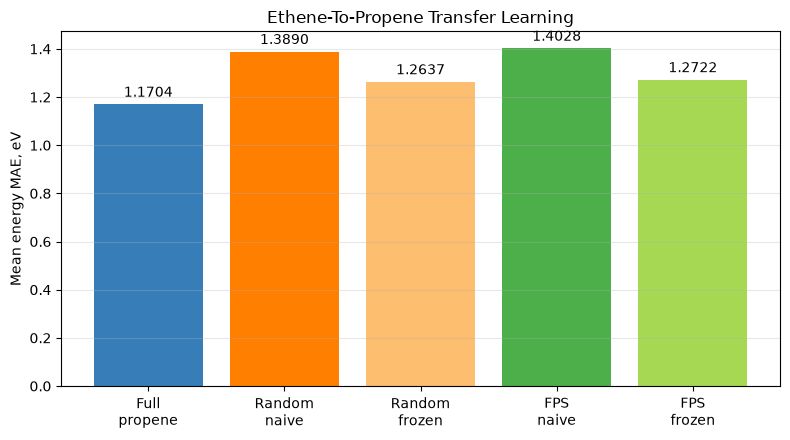

In [10]:
plot_labels = [
    "Full\npropene", "Random\nnaive", "Random\nfrozen",
    "FPS\nnaive", "FPS\nfrozen",
]
plot_maes = list(results.values())
plot_colors = ["#377eb8", "#ff7f00", "#fdbf6f", "#4daf4a", "#a6d854"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(plot_labels, plot_maes, color=plot_colors)
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_ylabel("Mean energy MAE, eV")
ax.set_title("Ethene-To-Propene Transfer Learning")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ethene_to_propene_comparison.png", dpi=150)
plt.show()

From the brief data, seems like there are a few important points 
1) The lightweight model is probably not enough to capture or represent propene. Maybe due to the irreps being too low. Ethene MAE was significantly better even with the lightweight model at 0.37eV, but even so this range is far from the target of <0.05eV. Likely need to use the default model for more meaingful results 
2) The full propene sample gives the "best" MAE error, not too surprising as it has the most data and is the baseline. 
3) Randomly sampling vs FPS doesnt really seem to affect the error much. In fact trying to sample from energies made the error abit larger. Very expected also that a random strat will fail. Probably need to repeat multiple times with different random seed to get some statistical significance 
4) Naive vs Frozen TL seems to have a larger ish impact on the error. BUT again not too significant considering the baseline is bad. Interestingly the loss for frozen is higher than naive, but likely due to some misalignment with the latent space cause loss to be large? but then end up prediction on the test set performs better